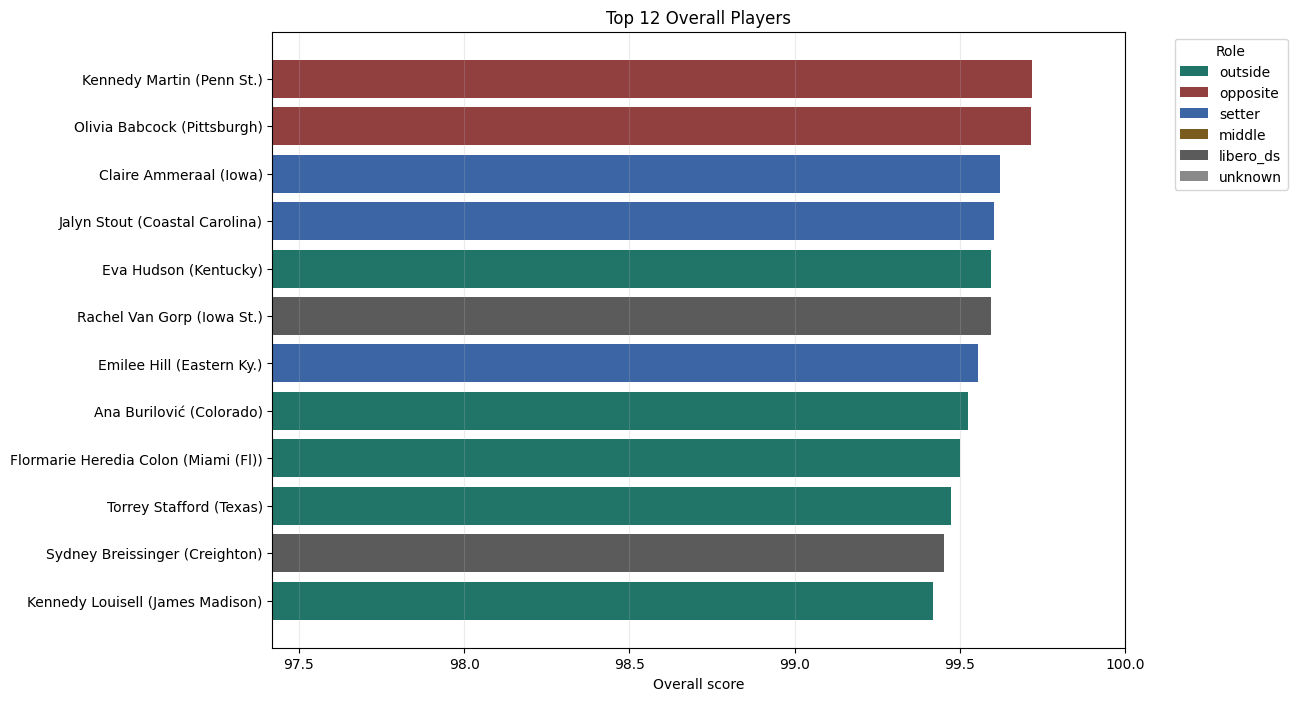

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

season = "2025-2026"
repo_root = Path.cwd()
if not (repo_root / "Data" / "model_outputs").exists():
    repo_root = repo_root.parent

rankings = pd.read_csv(repo_root / "Data" / "model_outputs" / f"player_rankings_{season}.csv")

role_colors = {
    "outside": "#207568",
    "opposite": "#923f3f",
    "setter": "#3b65a5",
    "middle": "#7a5c1f",
    "libero_ds": "#5b5b5b",
    "unknown": "#8a8a8a",
}

legend_elements = [Patch(facecolor=color, label=role) for role, color in role_colors.items()]

top = rankings.sort_values("overall_rank").head(12).sort_values("overall_score")
labels = top["player"] + " (" + top["team"] + ")"
colors = top["role_family"].map(role_colors).fillna("#8a8a8a")

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(labels, top["overall_score"], color=colors)
ax.set_title("Top 12 Overall Players")
ax.set_xlabel("Overall score")
ax.set_xlim(max(0, top["overall_score"].min() - 2), 100)
ax.grid(axis="x", alpha=0.25)
ax.legend(handles=legend_elements, title="Role", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()
